In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

# Package for regridding 
import xesmf as xe 

# Make nice plots with different projections 
import cartopy.crs as ccrs 

# Toolkit for sea level equation
import gravity_toolkit as gravtk

#from scipy import signal              
import importlib

# Functions to make the script more readable. 
import Kyrafunctions as ky

import sys
sys.path.append('../code')
import SeaLevelContrib as slc


In [2]:

importlib.reload(ky)


<module 'Kyrafunctions' from 'C:\\Users\\kyrab\\Github\\SLBudget\\notebooks\\Kyrafunctions.py'>

In [3]:
data_path = '../data/GravIs/'
output_path = '../outputs/Gravis_Antarctica/'

In [4]:
# Open the COST-G and GFZ dataset to compare 
ant = xr.open_dataset(data_path + "GRAVIS-3_COSTG_0100_AIS_GRID_TUD_0003.nc")
ant2 = xr.open_dataset(data_path + "GRAVIS-3_GFZOP_0600_AIS_GRID_TUD_0004.nc")




In [5]:
#Create a yearly dataset: (for now just take the mean) 
'''
# Drop dm, time_dec, and the old time coordinate: this is everything that dempends on time
ant_y = ant.drop_vars(['dm', 'time_dec', 'time'], errors='ignore')

# Resample dm to yearly
dm_y = ant['dm'].resample(time='1Y').mean(keep_attrs=True)
# Ensure correct order
dm_y = dm_y.transpose('time', 'y', 'x')

# Assign dm back
ant_y = ant_y.assign({'dm': dm_y})

# Assign the time coordinate from dm_y (now no conflicts)
ant_y = ant_y.assign_coords(time=dm_y['time'])

# Compute decimal year as a NumPy array
time_dec = ant_y["time"].dt.year 

# Add it as a new variable (not just a coordinate)
ant_y["time_dec"] = ("time", time_dec.data)

# Add metadata (optional but good practice)
ant_y["time_dec"].attrs = {
    "long_name": "Decimal year",
    "units": "year"
}

'''

ant_y = ky.yearlygrace(ant) 

#print(xr.testing.assert_equal(ant_y, ant_y2))

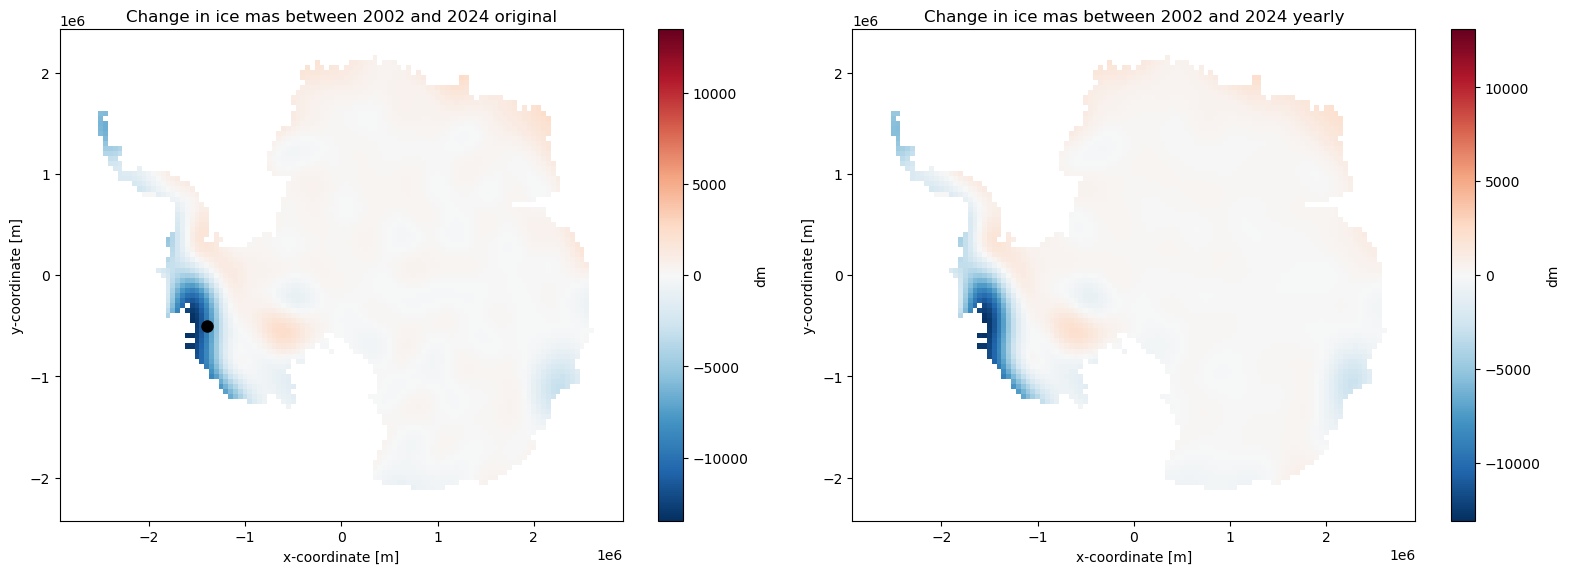

max_y
2204.1654761904756
max_orig
2557.3999999999996
min_y
-13072.07380952381
min_orig
-13452.0


In [6]:
# plot the two difference figures
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

(ant['dm'].isel(time=-1)-ant['dm'].isel(time=0)).plot(ax=ax1, cmap='RdBu_r')
ax1.set_title('Change in ice mas between 2002 and 2024 original')

x0 = -1400000     # example longitude
y0 = -500000     # example latitude
ax1.plot(x0, y0, 'o', markersize=8, color='black')  # dot


(ant_y['dm'].isel(time=-1) - ant_y['dm'].isel(time=0)).plot(ax=ax2, cmap='RdBu_r')
ax2.set_title('Change in ice mas between 2002 and 2024 yearly')
plt.tight_layout()
plt.show()

max_y = (ant_y['dm'].isel(time=-1) - ant_y['dm'].isel(time=0)).max()
print('max_y')
print(max_y.values)
max_orig = (ant['dm'].isel(time=-1) - ant['dm'].isel(time=0)).max()
print('max_orig')
print(max_orig.values)


# Minimum values
min_y = (ant_y['dm'].isel(time=-1) - ant_y['dm'].isel(time=0)).min()
print('min_y')
print(min_y.values)

min_orig = (ant['dm'].isel(time=-1) - ant['dm'].isel(time=0)).min()
print('min_orig')
print(min_orig.values)



# Check number of non-NaNs
#print("Number of non-NaNs in dm_y:", dm_y.count().values)
      
#display(ant_y)
#print(ant['time'].values)
#print(ant_y['time_dec'].values)

#ant['area'].plot()

# Save values for later use with nan values: 
#antnan = ant
#ant_ynan = ant_y

#display(ant_ynan)

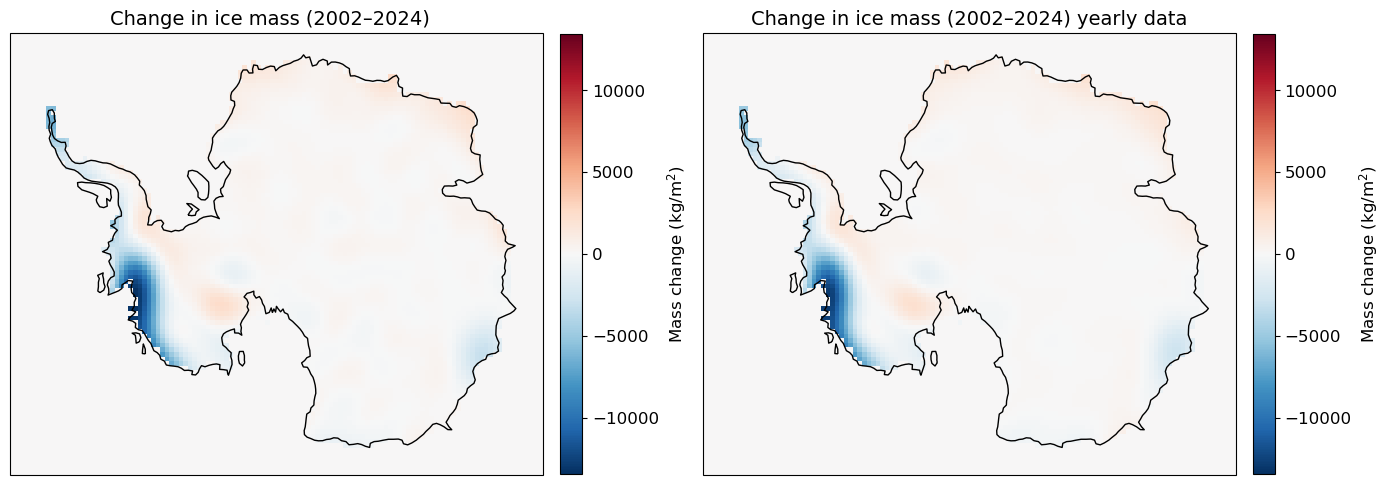

In [45]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Compute total changes (Antarctica)
change_orig = ant['dm'].isel(time=-1) - ant['dm'].isel(time=0)
change_year = ant_y['dm'].isel(time=-1) - ant_y['dm'].isel(time=0)

# Projection (South Polar Stereographic)
proj = ccrs.Stereographic(
    central_latitude=-90,
    central_longitude=0,
    true_scale_latitude=-71
)

# Symmetric color scale
vmax = np.nanmax(np.abs([
    change_orig.max().values,
    change_orig.min().values,
    change_year.max().values,
    change_year.min().values
]))

# Plot
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(14,6),
    subplot_kw={'projection': proj}
)

for ax, data, title in zip(
    [ax1, ax2],
    [change_orig, change_year],
    [" ", "yearly data"]
):
    pc = ax.pcolormesh(
        ant['x'], ant['y'], data,
        transform=proj,
        cmap='RdBu_r',
        vmin=-vmax, vmax=vmax,
        shading='auto'
    )
    ax.coastlines(resolution='110m')
    ax.set_title(f"Change in ice mass (2002–2024) {title}", fontsize =14)

    cbar = plt.colorbar(
        pc, ax=ax, orientation='vertical',
        pad=0.03, 
        fraction=0.0385
    )
    cbar.set_label("Mass change (kg/m$^2$)", fontsize=12)
    # Change the tick numbers size
    cbar.ax.tick_params(labelsize=12)


plt.tight_layout()
plt.show()






<xarray.DataArray 'dm' (time: 240)> Size: 2kB
[240 values with dtype=float64]
Coordinates:
    x        float64 8B -1.4e+06
    y        float64 8B -5e+04
  * time     (time) datetime64[ns] 2kB 2002-04-18 ... 2024-12-16T12:00:00
Attributes:
    long_name:      change in ice mass
    standard_name:  change_in_land_ice_amount
    units:          kg/m^2
    valid_max:      5002.6
    valid_min:      -8993.2

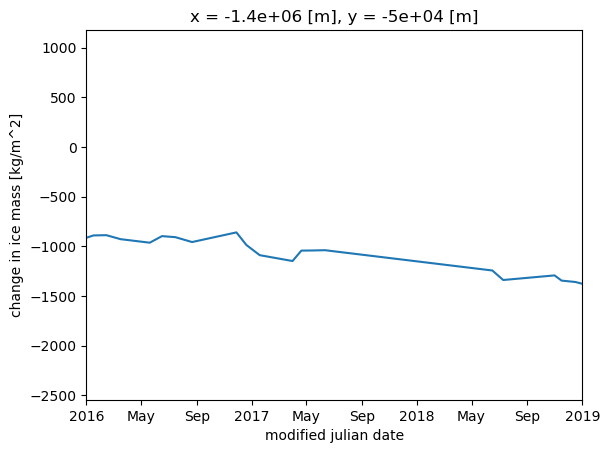

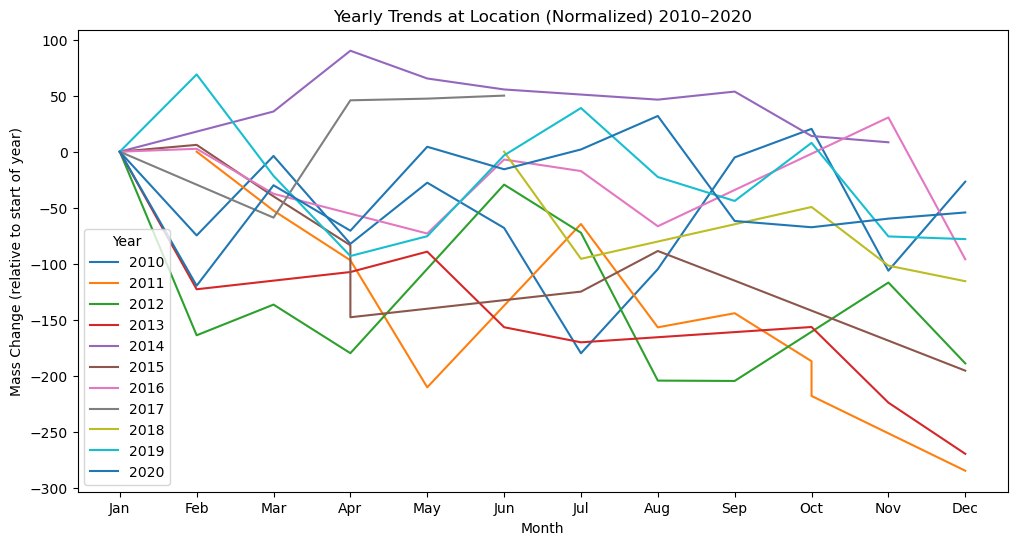

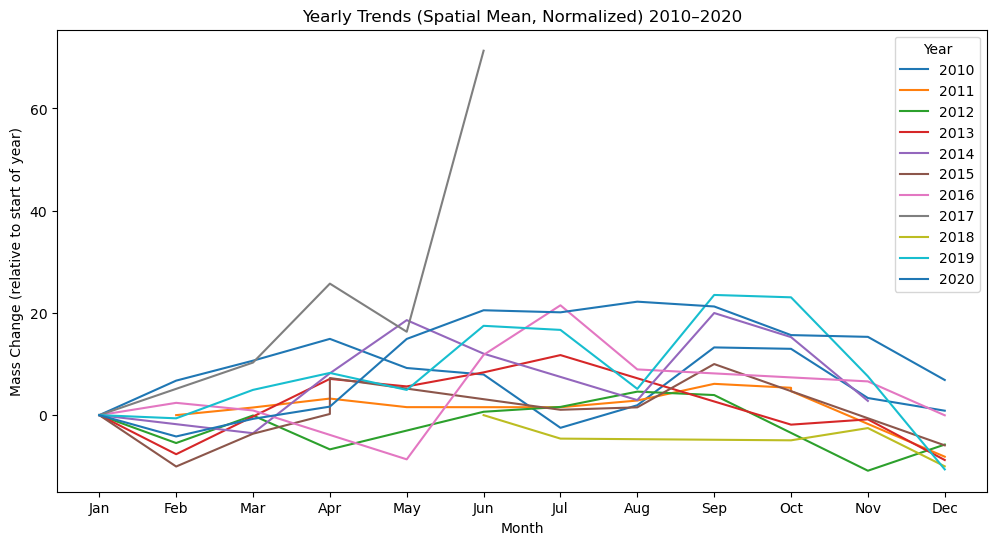

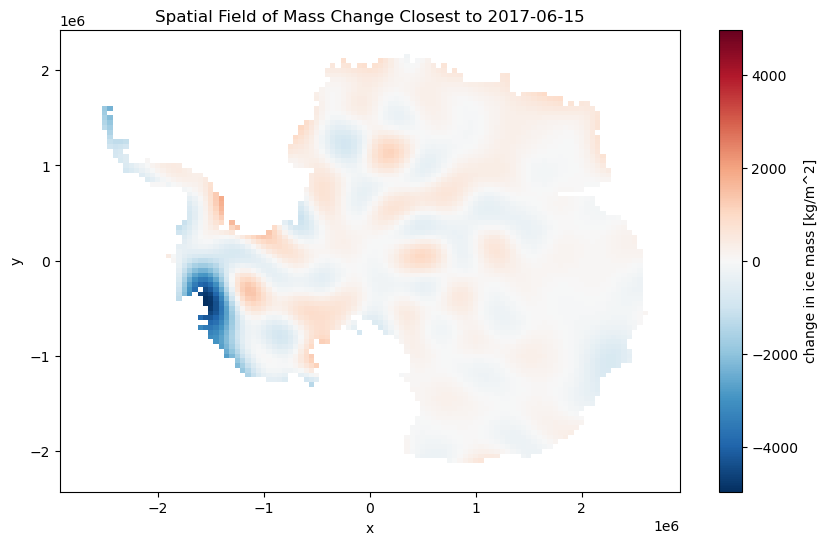

In [8]:
ant_orig = ant['dm'].sel(x=-1400000, y=-50000)
display(ant_orig)
ant_orig.plot()
plt.xlim(pd.Timestamp('2016-01-01'), pd.Timestamp('2019-01-01'))

import matplotlib.pyplot as plt

ant_orig = ant['dm'].sel(x=-1400000, y=-50000)

fig, ax = plt.subplots(figsize=(12, 6))

for year in range(2010, 2021):
    yearly = ant_orig.sel(time=str(year))
    if yearly.time.size == 0:
        continue

    # Normalize: first value of the year = 0
    yearly_norm = yearly - yearly.isel(time=0)

    # Extract month number for each time point
    months = yearly['time.month']

    ax.plot(months, yearly_norm, label=str(year))

# Set x-axis ticks as months
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

ax.set_xlabel("Month")
ax.set_ylabel("Mass Change (relative to start of year)")
ax.set_title("Yearly Trends at Location (Normalized) 2010–2020")
ax.legend(title="Year")
plt.show()



import matplotlib.pyplot as plt

# Compute the spatial mean over x and y
ant_mean = ant['dm'].mean(dim=['x', 'y'])

fig, ax = plt.subplots(figsize=(12, 6))

for year in range(2010, 2021):
    yearly = ant_mean.sel(time=str(year))
    if yearly.time.size == 0:
        continue

    # Normalize: first value of the year = 0
    yearly_norm = yearly - yearly.isel(time=0)

    # Extract month number for x-axis
    months = yearly['time.month']

    ax.plot(months, yearly_norm, label=str(year))

# Set x-axis ticks as months
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

ax.set_xlabel("Month")
ax.set_ylabel("Mass Change (relative to start of year)")
ax.set_title("Yearly Trends (Spatial Mean, Normalized) 2010–2020")
ax.legend(title="Year")
plt.show()




# Select the time closest to June 2017
target_date = '2017-06-15'  # mid-June
ant_june2017 = ant['dm'].sel(time=target_date, method='nearest')

# Plot the spatial field
plt.figure(figsize=(10, 6))
ant_june2017.plot(cmap='RdBu_r')
plt.title(f"Spatial Field of Mass Change Closest to {target_date}")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


2002-04-18T00:00:00.000000000 2024-12-16T12:00:00.000000000
Average mass loss rate (COST-G): -112.83 Gt/yr
Average mass loss rate (GFZ):    -107.43 Gt/yr
TOTAL MASS LOSS BETWEEN 2002 AND 2024:-2174420518290746.75 kg
-0.006023325535431431
<xarray.DataArray ()> Size: 8B
array(-6.01000696)


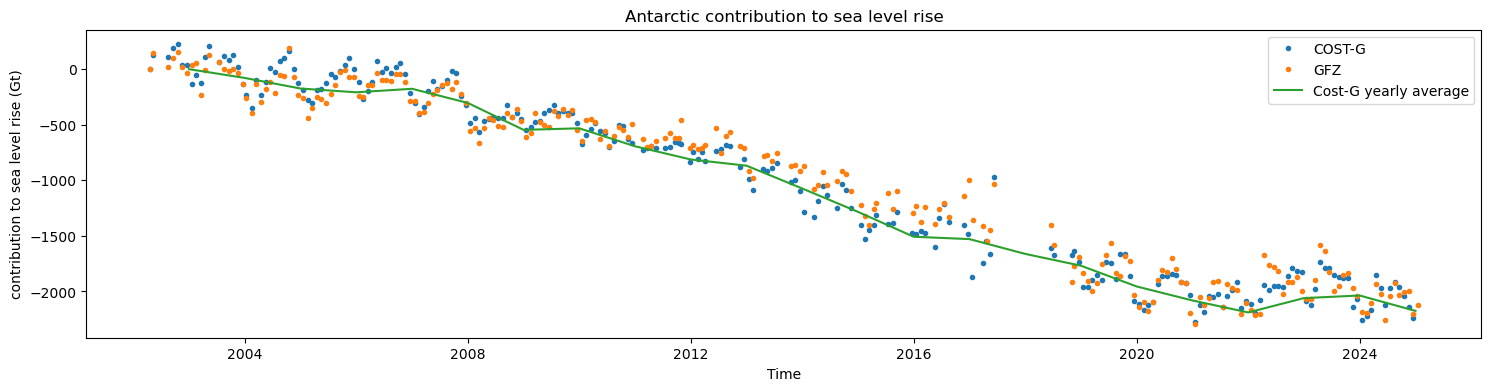

In [9]:

# Create dataset with total mass loss over Antarctica for the 2 datasets. 

antsum = (ant['dm']*ant['area']).sum(dim=['x', 'y'], skipna=True)*10**(-12)  # Multiply the dm (kg per square meter ice loss) with the area to ge total ice loss, then sum over all cells to get total mass loss and translate to Gt
antsum2 = (ant2['dm']*ant2['area']).sum(dim=['x', 'y'], skipna=True)*10**(-12)

#antsum = (ant_dm*ant['area']).sum(dim=['x', 'y'], skipna=True)*10**(-12)  # plot the yearly data
#antsum2 = (ant2['dm']*ant2['area']).sum(dim=['x', 'y'], skipna=True)*10**(-12)


# Represent values relative to the value at t=0
antsum_rel = antsum - antsum.isel(time=0)
antsum2_rel = antsum2 - antsum2.isel(time=0)


#print(gravis_data['time [yyyy-mm-dd]'].min(), gravis_data['time [yyyy-mm-dd]'].max())
print(antsum_rel['time'].min().values, antsum_rel['time'].max().values)


#Determine the trend - CHECK THIS CODE
# Make numeric array of years plus fractin of the days. 
time_years = antsum['time'].dt.year + antsum['time'].dt.dayofyear / 365.25
time_years2 = antsum2['time'].dt.year + antsum2['time'].dt.dayofyear / 365.25
# Linear trend (slope = Gt/yr)
slope1, intercept1 = np.polyfit(time_years, antsum_rel, 1)
slope2, intercept2 = np.polyfit(time_years2, antsum2_rel, 1)
print(f"Average mass loss rate (COST-G): {slope1:.2f} Gt/yr")
print(f"Average mass loss rate (GFZ):    {slope2:.2f} Gt/yr")


# Check total mass loss between 2002 and now based on ant_y

antsumyear = (ant_y['dm']*ant['area']).sum(dim=['x', 'y'], skipna=True)*10**(-12) 

totalmassant = (antsumyear.isel(time=-1)-antsumyear.isel(time=0))*1e12 #from gt back to kg
print(f"TOTAL MASS LOSS BETWEEN 2002 AND 2024:{totalmassant:.2f} kg")

totalvolume = totalmassant/1000
oceansurf = 361000000000000
meanrise = totalvolume/oceansurf
print(meanrise.values) 

print(totalmassant*(1e-12)/361.8)


#Make a figure 
plt.figure(figsize=(18,4)) 


#plt.plot(gravis_data['time [yyyy-mm-dd]'], Gravistest, label='GRAVIS_directly', color='black', linestyle='-', marker='')

antsum_rel.plot(marker='.', linestyle='', label='COST-G') #multiply antsum by 1.2 to line up with the black line.. .that is weird 
antsum2_rel.plot(marker='.', linestyle='', label='GFZ')
(antsumyear-antsumyear.isel(time=0)).plot(label='Cost-G yearly average')


plt.xlabel("Time")
plt.ylabel("contribution to sea level rise (Gt)")
plt.title("Antarctic contribution to sea level rise")
plt.legend()
plt.show()



## Try to calculate the total mass loss Antarctica

In [10]:
#check times
#time_list = antsum["time"].dt.strftime("%Y-%m-%d").values
#print(time_list)
#print(antsum['dm'].values)
# antsum is your 1D DataArray: sum over all coordinates per timestep
#antsum_interp = antsum.interpolate_na(dim="time", method="linear")
#antsum_interp.plot(marker='.', linestyle='', figsize=(12,4))



## Regridding to use GRD in the proper grid (lon, lat grid) 

In [11]:
print(np.isnan(ant['dm']).mean().item())     # fraction NaN before resampling
print(np.isnan(ant_y['dm']).mean().item())   # fraction NaN after resampling

0.5689488060622081
0.5689488060622081


<xarray.Dataset> Size: 523kB
Dimensions:   (lat: 180, lon: 360)
Coordinates:
  * lon       (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * lat       (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
Data variables:
    mask      (lat, lon) float32 259kB nan nan nan nan nan ... 1.0 1.0 1.0 1.0
    mask_med  (lat, lon) float32 259kB ...
Attributes:
    source_file:    This NetCDF file was built from the script ExtractReferen...
    creation_date:  2020-08-05 16:30

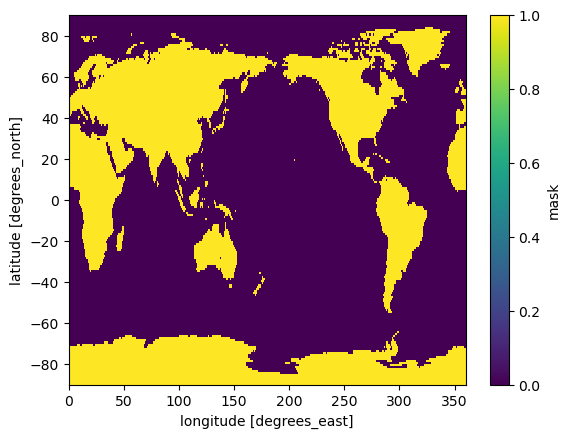

In [12]:
# Define the reference mask: 

path_masks = '/Users/kyrab/Github/SLBudget/data/Masks/'
masks_ds = xr.open_dataset(f'{path_masks}reference_masks.nc')

landsea = xr.where(masks_ds.mask==1, 0, 1)
landsea.plot()
#print(masks_ds['lat'].values)

#landsea

display(masks_ds)

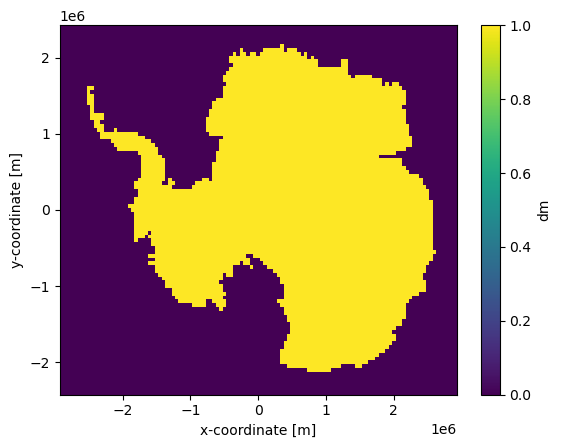

In [13]:
Aant = ant
Aant_y = ant_y


maskje1 = xr.where(np.isnan((Aant_y['dm'].isel(time=-1) - Aant_y['dm'].isel(time=0))), 0, 1)
maskje1.plot()
areabeforeregridding = (Aant_y['area']*maskje1).sum(dim=['x', 'y'], skipna=True)



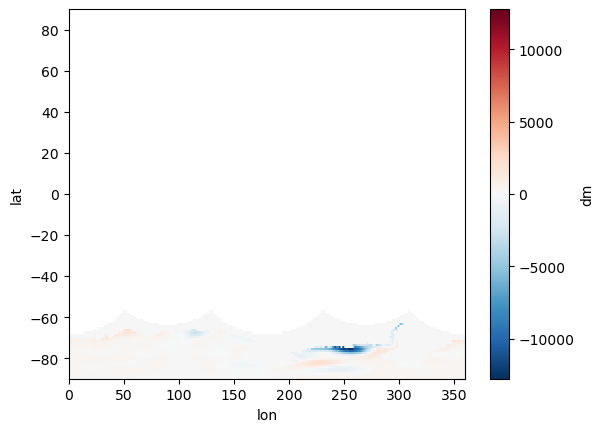

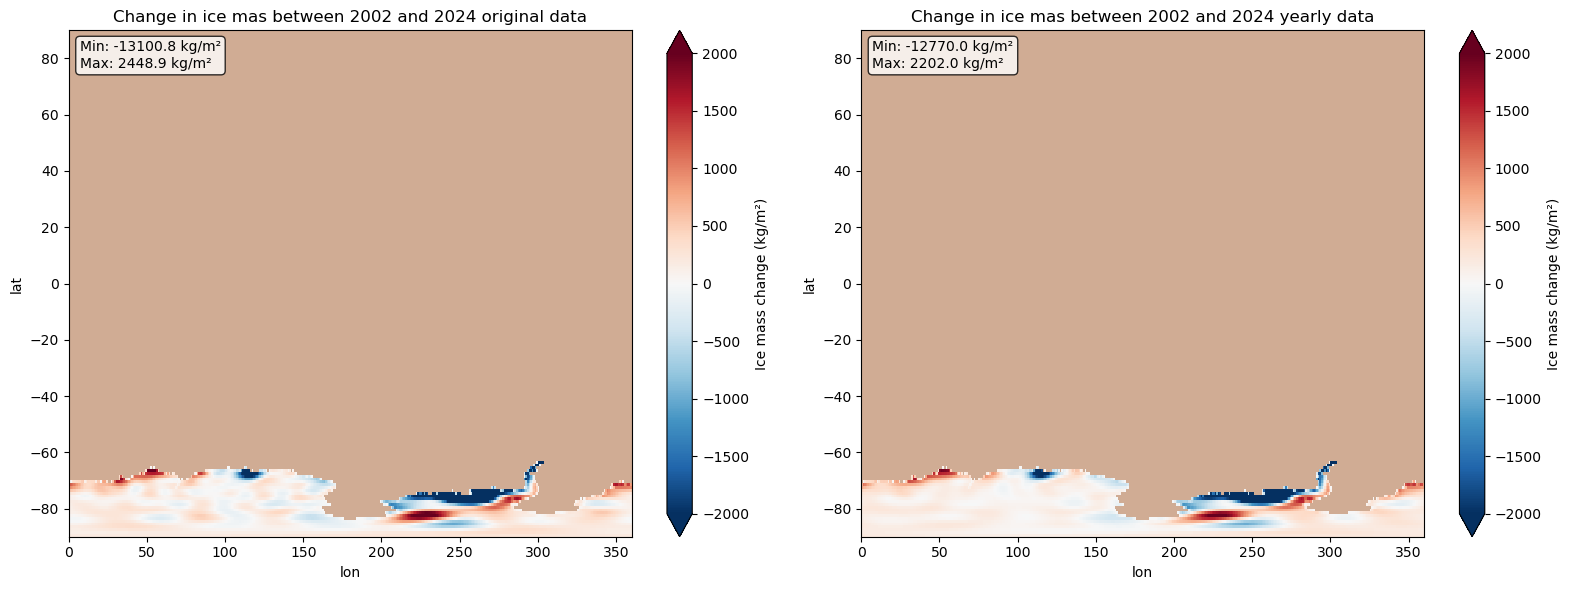

In [14]:
# Regridding 

#define resolution reference grid (needs to have the same dimensions as the mask
#lon_res = 1
#lat_res = 1

#lon_target = np.arange(0, 360 , lon_res)
#lat_target = np.arange(-90, 90 , lat_res)  # (this should be until 90+lat_res otherwise you miss one pole??


# Or use the lon and lat values from the mask directly: Here, points are defined between 2 degrees. It contains for lat all values 89.5 - N*1 with N in N
lon_target = masks_ds['lon'].values
lat_target = masks_ds['lat'].values 


lon2d, lat2d = np.meshgrid(lon_target, lat_target)   #creates lon lat pairs


# CHECK WHY THIS IS EXactly 
ds_out = xr.Dataset(
    {
        "lat": (["lat", "lon"], lat2d),
        "lon": (["lat", "lon"], lon2d)
    }
)



# First make sure nans are filled with zeros. Do that before regridding in stead of after. 
ant['dm'] = ant['dm'].fillna(0)
ant_y['dm'] = ant_y['dm'].fillna(0)
#print(ant['dm'].min().values)

#(ant_y['dm'].isel(time=-1) - ant_y['dm'].isel(time=0)).plot(cmap='RdBu_r')
#plt.show()

# Create the regridder. Array dataset containin lat lon values. 
regridder1 = xe.Regridder(ant, ds_out, "bilinear", periodic=False, reuse_weights=False, unmapped_to_nan=True)
regridder = xe.Regridder(ant_y, ds_out, "bilinear", periodic=False, reuse_weights=False, unmapped_to_nan=True)  # Periodic true does not work for some reason in this region... you need apparently full latitude coverage


# Regrid dm to lon-lat grid
dm_lonlat1 = regridder1(ant["dm"], keep_attrs=True)
dm_lonlat = regridder(ant_y["dm"], keep_attrs=True)
# Optional: Regrid area too if you need to recompute total mass
#area_lonlat = regridder(ant_y["area"], keep_attrs=True)


# Replace NANs with zeros: then there will be no mass change at areas that are not defined in the ant map
dm_lonlat_zero1 = dm_lonlat1.fillna(0)
dm_lonlat_zero = dm_lonlat.fillna(0) 

#area_lonlat_zero = area_lonlat.fillna(0)


# Compute total mass per time step in Gt ---
# 1 Gt = 1e12 kg
#total_mass_gt = (dm_lonlat_zero * area_lonlat_zero).sum(dim=("lat", "lon")) * 1e-12
#print(total_mass_gt)


'''
# --- Step 5: Store in xarray dataset for saving / plotting ---
ds_mass = xr.Dataset(
    {
        "dm_lonlat": dm_lonlat,
        "area_lonlat": area_lonlat,
        "total_mass_gt": total_mass_gt
    },
    coords={
        "time": ant_y["time"],
        "lat": (["lat", "lon"], lat2d),
        "lon": (["lat", "lon"], lon2d)
    }
)

# --- save to netcdf??
#ds_mass.to_netcdf("dm_lonlat_mass.nc")

'''

#plot 1
totalant1 = dm_lonlat_zero1.isel(time=-1) - dm_lonlat_zero1.isel(time=0)
totalant = dm_lonlat_zero.isel(time=-1) - dm_lonlat_zero.isel(time=0)
#totalant = dm_lonlat.isel(time=-1) - dm_lonlat.isel(time=0)
#totalant1 = dm_lonlat1.isel(time=-1) - dm_lonlat1.isel(time=0)

totalant_withnan = dm_lonlat.isel(time=-1) - dm_lonlat.isel(time=0)
totalant_withnan.plot()
plt.show()

#Make a figure: 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

totalant1.plot(ax=ax1, cmap="RdBu_r", vmin=-2000, vmax=2000,
        cbar_kwargs={
        'label': 'Ice mass change (kg/m²)',
        'shrink':1,                # Scale colorbar size
        'aspect':20   # in this case it is 20 times longer than it is wide            
    }
)

# --- Right plot: only zeros ---
zero_map = totalant1.where(np.isclose(totalant1, 0, atol=1e-6))
zero_map.plot(
    ax=ax1,
    cmap="pink",  # uniform pink color
    add_colorbar=False
)



ax1.set_title('Change in ice mas between 2002 and 2024 original data')




#min and max values for plot 1
min_val1 = totalant1.min().values
max_val1 = totalant1.max().values
ax1.text(0.02, 0.98, f'Min: {min_val1:.1f} kg/m²\nMax: {max_val1:.1f} kg/m²',
         transform=ax1.transAxes, 
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
         fontsize=10)





totalant.plot(ax=ax2, cmap="RdBu_r", vmin=-2000, vmax=2000,
        cbar_kwargs={
        'label': 'Ice mass change (kg/m²)',
        'shrink':1,                # Scale colorbar size
        'aspect':20   # in this case it is 20 times longer than it is wide            
    }
)


# --- Right plot: only zeros ---
zero_map = totalant.where(np.isclose(totalant, 0, atol=1e-6))
zero_map.plot(
    ax=ax2,
    cmap="pink",  # uniform pink color
    add_colorbar=False
)

ax2.set_title('Change in ice mas between 2002 and 2024 yearly data')
# Add min/max text to plot 2
min_val2 = totalant.min().values
max_val2 = totalant.max().values
ax2.text(0.02, 0.98, f'Min: {min_val2:.1f} kg/m²\nMax: {max_val2:.1f} kg/m²',
         transform=ax2.transAxes,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
         fontsize=10)
plt.tight_layout()
plt.show()

#totalant



# Save as NetCDF file
#totalant.to_netcdf(output_path + 'totalant_mass_change.nc')

# Later, reopen it:
#totalant_loaded = xr.open_dataarray(output_path + 'totalant_mass_change.nc')
#totalant_loaded.plot()
#totalant_loaded.close()


🧊 Total mass loss Antarctica between 2002 and 2024:            -2.174420518290746e+15 kg
🏔  Total mass decrease Antarctica calculated after regridding:  -2.188595343764459e+15 kg
Total area before regridding
1.251e+13
Total area after regridding
1.318e+13
Difference in area in m2
-6.701e+11
missing mass losss in Gt
-6701.43414205002
Difference in mass loss in gt
14.1748254737125


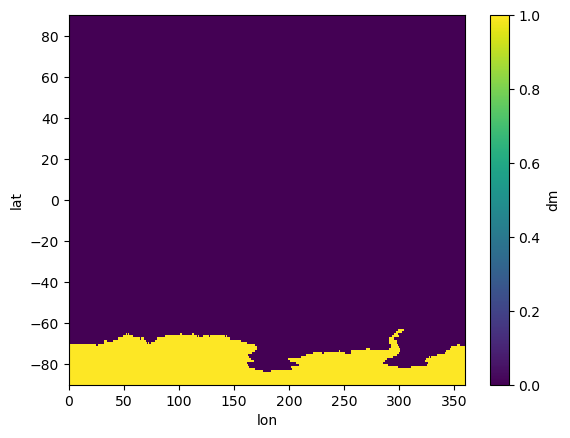

In [15]:
#check the areas before and after regridding
LMAX = 360

# Check if the total addeed mass is equal to the total mass loss of antarctica


# First, compute the area of each cell

# Get the average radius of the eath [cm] using LMAX (same method as in GRD patterns) 
factors = gravtk.units(lmax=LMAX)
rad_e = factors.rad_e/10**5 # Convert to km
rad_e_m = rad_e*1000 #convert to meters

area_da = landsea.copy()

deg2rad = np.pi/180
area_d1 = rad_e_m**2*np.cos(area_da.lat*deg2rad)*deg2rad**2   #calculate for every lat and lon combination the area. actually it depends only on latitude 

area_da.data = area_d1.data[:,np.newaxis]*np.ones(len(area_da.lon))

area_da.name = 'cell area [m**2]'

#this can only be done after running the sea level equation so this needs to be done afterwards 

#oc_vol_change = area_da*rsl_da/100 #assuming rsl is given in cm
#tot_vol_change = oc_vol_change.sum()

#rho = 1000 #kg/m3
#total_kig_added = tot_vol_change*rho  #assuming for now 1000 kg/m3, the same as used in the GRD patterns now

#print('kg added')
#print(total_kig_added.data)

#print(f"🌊 Total added water mass to the ocean:                          {total_kig_added.data:,.15e} kg")


# Check total mass loss between 2002 and now based on ant_y

antsumyear = (ant_y['dm']*ant_y['area']).sum(dim=['x', 'y'], skipna=True)    # ant/y in kg/m^2 per year and area in m2.. 


totalmassant = (antsumyear.isel(time=-1) - antsumyear.isel(time=0))         #from gt back to kg
#print(f"TOTAL MASS LOSS BETWEEN 2002 AND 2024:{totalmassant1:.3e} kg")

print(f"🧊 Total mass loss Antarctica between 2002 and 2024:            {totalmassant:.15e} kg")

#now calculate the total removed mass according to the regridded map: 
regriddedchange = area_da * totalant 
regriddedchange_tot = regriddedchange.sum()
print(f"🏔  Total mass decrease Antarctica calculated after regridding:  {regriddedchange_tot:.15e} kg")



#maskje1 = xr.where(np.isnan((Aant_y['dm'].isel(time=-1) - Aant_y['dm'].isel(time=0))), 0, 1)
#maskje1.plot()

areabeforeregridding = (Aant_y['area']*maskje1).sum(dim=['x', 'y'], skipna=True)
#areabeforeregridding = ant_y['area'].sum(dim=['x', 'y'], skipna=True)
print('Total area before regridding')
print(f"{areabeforeregridding.values:.3e}")


#create a mask array which is 1 for all totalant_withnan values with valid data
#maskje = xr.where(np.isnan(totalant_withnan), 0, 1)
#maskje.plot()

# this only works because the values in the totalant are never exactly 0. When this becomes true the code has to be adjusted
maskje = xr.where(
    (np.isnan(totalant_withnan)) | (totalant_withnan == 0),
    0,
    1
)
maskje.plot()


areaafterregridding = area_da*maskje
totalareaafter = areaafterregridding.sum()
print('Total area after regridding')
print(f"{totalareaafter.values:.3e}")

areadif = areabeforeregridding - totalareaafter
print('Difference in area in m2')
print(f"{areadif.values:.3e}")



# assume a mass loss of 10000 kg/m2 on average for missing areas
print('missing mass losss in Gt')
print((areadif*10000*10**(-12)).values)


differenceloss = totalmassant - regriddedchange_tot
print('Difference in mass loss in gt')
print(differenceloss.values*10**(-12))






# now a new reference map can be defined for regridding algorithm ! Adjust that later in the function 






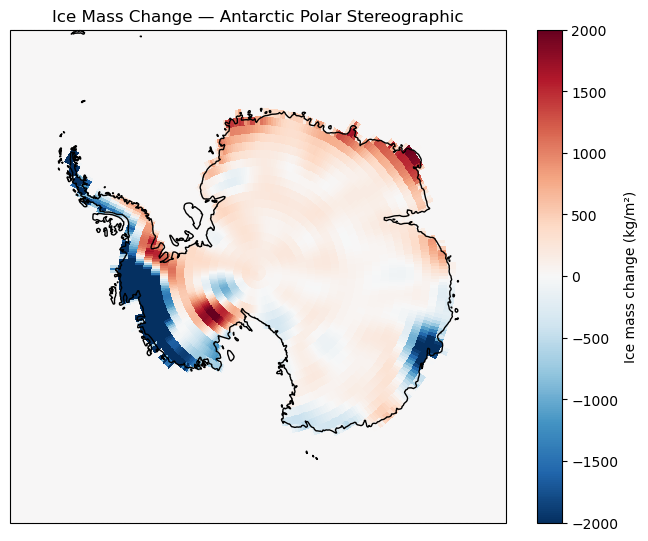

In [16]:

import cartopy.crs as ccrs

# Define the Antarctic Polar Stereographic projection (EPSG:3031)
antarctic_crs = ccrs.SouthPolarStereo()

# Create a single plot (not a subplot grid)
plt.figure(figsize=(8, 8))
#ax = plt.axes(projection=antarctic_crs)
ax = plt.axes(projection=antarctic_crs)

# Add context layers
ax.coastlines()#resolution='110m', color='black', linewidth=0.8)
#ax.gridlines(draw_labels=False, color='gray', linestyle='--', linewidth=0.5)
#ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())  # view over Antarctica
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())  # view over Antarctica

# Plot the data
mesh = ax.pcolormesh(
    totalant['lon'], totalant['lat'], totalant,
    #landsea['lon'], landsea['lat'], landsea,
    transform=ccrs.PlateCarree(),  # because lon/lat are in degrees (WGS84)
    cmap="RdBu_r",
    vmin=-2000, vmax=2000
)

# Add colorbar
cbar = plt.colorbar(
    mesh, ax=ax, orientation='vertical',
    shrink=0.8, aspect=20, pad=0.05,
    label='Ice mass change (kg/m²)'
)

plt.title("Ice Mass Change — Antarctic Polar Stereographic", fontsize=12)
plt.show()


<xarray.DataArray (lat: 180, lon: 360)> Size: 518kB
array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(180, 360))
Coordinates:
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5

<class 'xarray.core.dataarray.DataArray'>


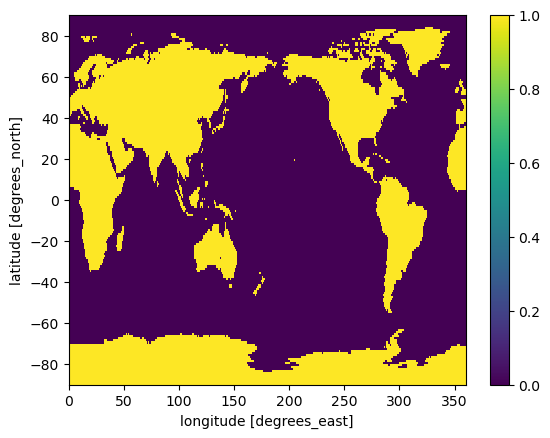

In [17]:
union_mask = xr.where((landsea == 1) | (maskje == 1), 1, 0)
# where landsea is 0 (water) and makje is 1, mass is added at the ocean, which apparently does not work for the sealevelequation. So therefore we take the union to make sure all mass is added on land. 
testmask = xr.where((landsea == 0) | (maskje == 1), 1, 0)  
# the next plot shows there are some areas at antarctica where mass is added at regions defined as sea in the original mask, so therefore the union mask is created. 
#testmask.plot()
#plt.show()
union_mask.plot()

display(union_mask)

print(type(union_mask))


# Example: save in a folder called 'masks' on your C: drive
#union_mask.to_netcdf(output_path2 + 'union_mask.nc')

#


In [18]:
# Calculate the colatitude in radians: 

th = (90 - lat_target)*np.pi/180.0
LMAX = 360
LOVE = gravtk.load_love_numbers(LMAX)
PLM, dPLM = gravtk.plm_holmes(LMAX, np.cos(th))
LOVE0 = (LOVE[0]-LOVE[0], LOVE[1]-LOVE[1], LOVE[2]-LOVE[2])


In [19]:
# Method 2 from notebook ComputeGRD
#tptalant=dm_diff
#It uses a dinsity of 1 standard but that is not realistic I think??? SOLVE THIS!!
Ylms = gravtk.gen_stokes(totalant.data.T, lon_target, lat_target, UNITS=3, LMIN=0, LMAX=LMAX, LOVE=LOVE, PLM=PLM)
Ylms_L0 = gravtk.gen_stokes(totalant.data.T, lon_target, lat_target, UNITS=3, LMIN=0, LMAX=LMAX, LOVE=LOVE0, PLM=PLM)
#Ylms = gravtk.gen_stokes(dm_diff.data.T, lon_target, lat_target, UNITS=3, LMIN=0, LMAX=LMAX, LOVE=LOVE, PLM=PLM)
#Ylms_L0 = gravtk.gen_stokes(dm_diff.data.T, lon_target, lat_target, UNITS=3, LMIN=0, LMAX=LMAX, LOVE=LOVE0, PLM=PLM)



Ylms

print("Ylms.clm shape:", Ylms.clm.shape)
print("lon_target:", len(lon_target))
print("lat_target:", len(lat_target))
print("landsea shape:", landsea.shape)
print('lalal')

Ylms.clm shape: (361, 361)
lon_target: 360
lat_target: 180
landsea shape: (180, 360)
lalal


<xarray.DataArray (lat: 180, lon: 360)> Size: 518kB
array([[       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       ...,
       [0.71099374, 0.71017087, 0.70849767, ..., 0.70805089, 0.70990778,
        0.71090705],
       [0.68014654, 0.67680813, 0.67399717, ..., 0.69250639, 0.68808576,
        0.68393465],
       [0.71828421, 0.71612912, 0.71394707, ..., 0.72452826, 0.72248977,
        0.72040642]], shape=(180, 360))
Coordinates:
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5

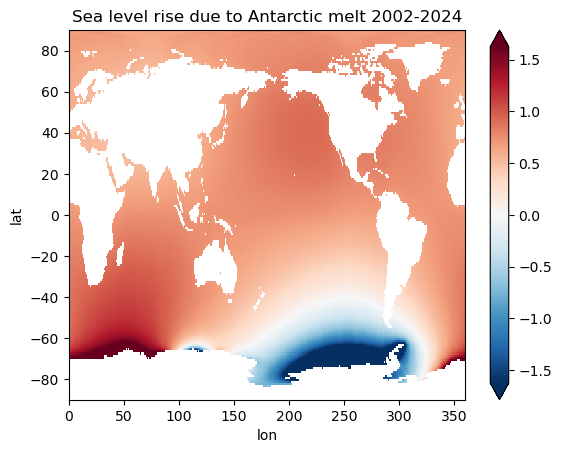

In [20]:
rsl = gravtk.sea_level_equation(Ylms.clm, Ylms.slm, lon_target, lat_target, union_mask.data.T, #landsea.data.T,
    LMAX=LMAX, PLM=PLM, LOVE=LOVE, ITERATIONS=6, POLAR=True)

rsl_da = xr.DataArray(
    data=rsl.T,              # transpose if needed
    dims=["lat", "lon"],     # match array shape
    coords={"lat": lat_target, "lon": lon_target}
)


rsl_da = rsl_da.where(union_mask != 1, np.nan)


(rsl_da).plot(robust=True, cmap="RdBu_r")
plt.title('Sea level rise due to Antarctic melt 2002-2024')

rsl_da

<xarray.DataArray ()> Size: 8B
array(0.52569035)


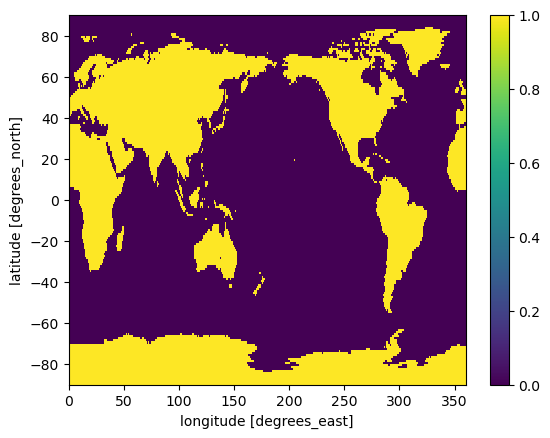

In [21]:
union_mask.plot()
meanrise = rsl_da.mean()
masked_mean = rsl_da.where(union_mask == 0).mean()
print(masked_mean)
#print(meanrise)

🌊 Total added water mass to the ocean:                          2.188595343764459e+15 kg
🧊 Total mass loss Antarctica between 2002 and 2024:            -2.174420518290746e+15 kg
🏔  Total mass decrease Antarctica calculated after regridding:  -2.188595343764459e+15 kg
Total area before regridding
1.251e+13
Total area after regridding
1.318e+13
Difference in area in m2
-6.701e+11
missing mass losss in Gt
-6701.43414205002
Difference in mass loss in gt
14.1748254737125


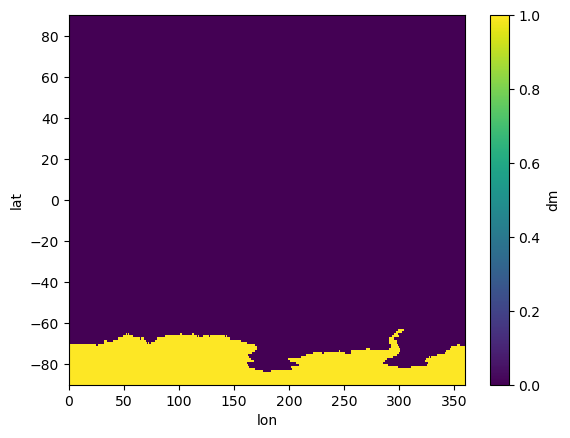

In [22]:
# Check if the total addeed mass is equal to the total mass loss of antarctica


# First, compute the area of each cell

# Get the average radius of the eath [cm] using LMAX (same method as in GRD patterns) 
factors = gravtk.units(lmax=LMAX)
rad_e = factors.rad_e/10**5 # Convert to km
rad_e_m = rad_e*1000 #convert to meters

area_da = landsea.copy()

deg2rad = np.pi/180
area_d1 = rad_e_m**2*np.cos(area_da.lat*deg2rad)*deg2rad**2   #calculate for every lat and lon combination the area. actually it depends only on latitude 

area_da.data = area_d1.data[:,np.newaxis]*np.ones(len(area_da.lon))

area_da.name = 'cell area [m**2]'
#area_da.plot()

# Check the computation of the area is done in compute grd patterns and there it is shown it is similar
#earth_surf_area = 4*np.pi*rad_e**2
#print('Analytical computation')
#print(earth_surf_area)
#print('Sum of grid')
#print(area_da.sum().data)

oc_vol_change = area_da*rsl_da/100 #assuming rsl is given in cm
tot_vol_change = oc_vol_change.sum()

rho = 1000 #kg/m3
total_kig_added = tot_vol_change*rho  #assuming for now 1000 kg/m3, the same as used in the GRD patterns now

#print('kg added')
#print(total_kig_added.data)
print(f"🌊 Total added water mass to the ocean:                          {total_kig_added.data:,.15e} kg")


# Check total mass loss between 2002 and now based on ant_y

antsumyear = (ant_y['dm']*ant_y['area']).sum(dim=['x', 'y'], skipna=True)    # ant/y in kg/m^2 per year and area in m2.. 


totalmassant = (antsumyear.isel(time=-1) - antsumyear.isel(time=0))         #from gt back to kg
#print(f"TOTAL MASS LOSS BETWEEN 2002 AND 2024:{totalmassant1:.3e} kg")

print(f"🧊 Total mass loss Antarctica between 2002 and 2024:            {totalmassant:.15e} kg")

#now calculate the total removed mass according to the regridded map: 
regriddedchange = area_da * totalant 
regriddedchange_tot = regriddedchange.sum()
print(f"🏔  Total mass decrease Antarctica calculated after regridding:  {regriddedchange_tot:.15e} kg")



#maskje1 = xr.where(np.isnan((Aant_y['dm'].isel(time=-1) - Aant_y['dm'].isel(time=0))), 0, 1)
#maskje1.plot()

areabeforeregridding = (Aant_y['area']*maskje1).sum(dim=['x', 'y'], skipna=True)
#areabeforeregridding = ant_y['area'].sum(dim=['x', 'y'], skipna=True)
print('Total area before regridding')
print(f"{areabeforeregridding.values:.3e}")


#create a mask array which is 1 for all totalant_withnan values with valid data
#maskje = xr.where(np.isnan(totalant_withnan), 0, 1)
#maskje.plot()

# this only works because the values in the totalant are never exactly 0. When this becomes true the code has to be adjusted
maskje = xr.where(
    (np.isnan(totalant_withnan)) | (totalant_withnan == 0),
    0,
    1
)
maskje.plot()


areaafterregridding = area_da*maskje
totalareaafter = areaafterregridding.sum()
print('Total area after regridding')
print(f"{totalareaafter.values:.3e}")

areadif = areabeforeregridding - totalareaafter
print('Difference in area in m2')
print(f"{areadif.values:.3e}")



# assume a mass loss of 10000 kg/m2 on average for missing areas
print('missing mass losss in Gt')
print((areadif*10000*10**(-12)).values)


differenceloss = totalmassant - regriddedchange_tot
print('Difference in mass loss in gt')
print(differenceloss.values*10**(-12))



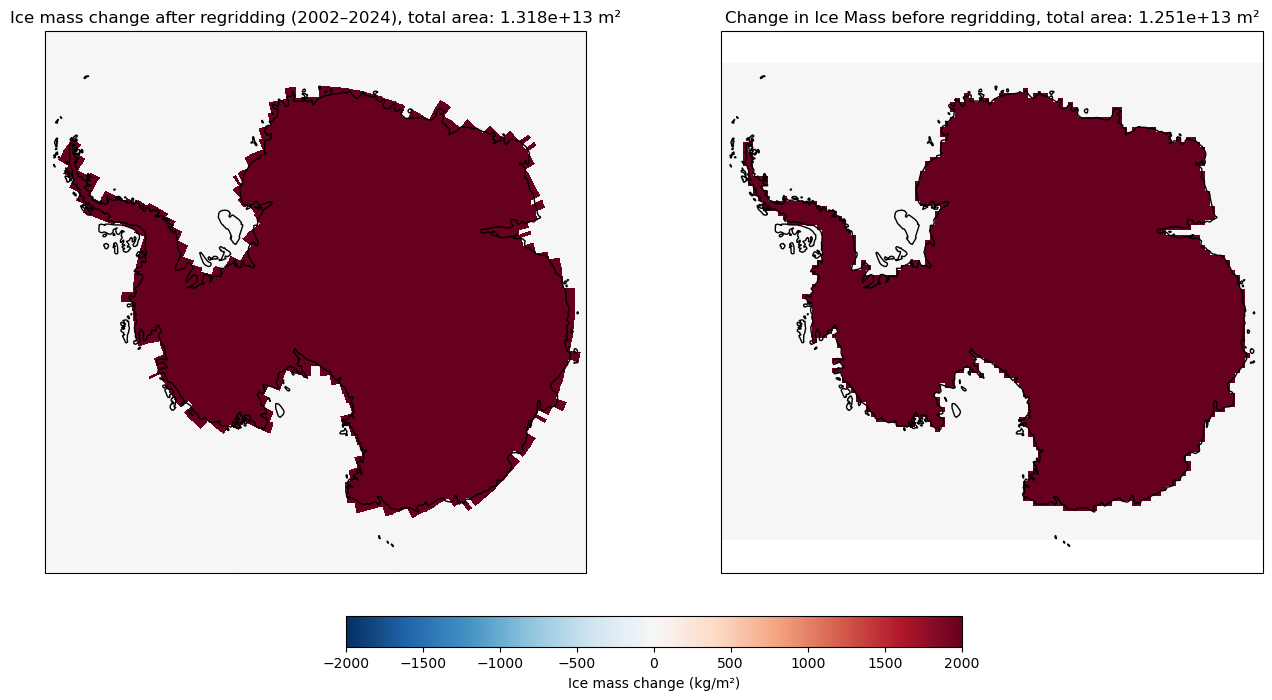

minimum before regridding
-13072.07380952381
miniumum after regridding
-12770.034593314791


In [23]:
import cartopy.crs as ccrs
import numpy as np
import matplotlib.pyplot as plt

antarctic_crs = ccrs.SouthPolarStereo()

diff = ant_y['dm'].isel(time=-1) - ant_y['dm'].isel(time=0)

# Automatically get min and max of data
#vmin = np.nanmin(diff)
#vmax = np.nanmax(diff)

# Create both subplots with the same projection
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(16, 8),
    subplot_kw={'projection': antarctic_crs}
)

# --- Left subplot: Antarctic map ---
ax1.coastlines()
ax1.set_extent([-180, 180, -90, -65], ccrs.PlateCarree())

mesh1 = ax1.pcolormesh(
    totalant_withnan['lon'], totalant_withnan['lat'], areaafterregridding,#totalant_withnan,
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r',
    vmin=-2000, vmax=2000
)
ax1.set_title(f"Ice mass change after regridding (2002–2024), total area: {totalareaafter:.3e} m²")

# --- Right subplot: Antarctic map ---
diff = ant_y['dm'].isel(time=-1) - ant_y['dm'].isel(time=0)

mesh2 = ax2.pcolormesh(
    ant_y['lon'], ant_y['lat'], (Aant_y['area']*maskje1), # diff,
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r',
    vmin=-2000, vmax=2000
)
ax2.coastlines()
ax2.set_extent([-180, 180, -90, -65], ccrs.PlateCarree())
ax2.set_title(f"Change in Ice Mass before regridding, total area: {areabeforeregridding:.3e} m²")

# --- Shared colorbar ---
cbar = fig.colorbar(mesh2, ax=[ax1, ax2], orientation='horizontal', fraction=0.05, pad=0.07)
cbar.set_label('Ice mass change (kg/m²)')

plt.show()


print('minimum before regridding')
print(diff.min().values)
print('miniumum after regridding')
print(totalant.min().values)

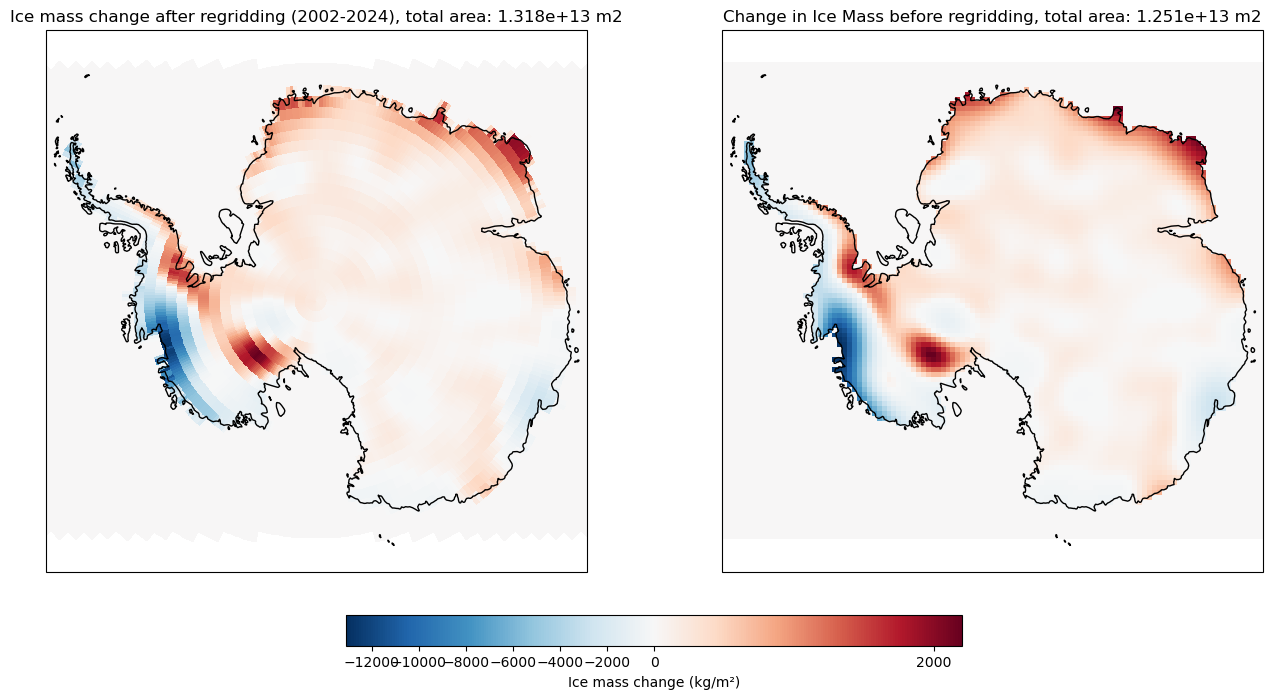

In [24]:
import cartopy.crs as ccrs
import numpy as np
from matplotlib.colors import TwoSlopeNorm

antarctic_crs = ccrs.SouthPolarStereo()


diff = ant_y['dm'].isel(time=-1) - ant_y['dm'].isel(time=0)

# Automatically get min and max of data
vmin = np.nanmin(diff)
vmax = np.nanmax(diff)

# Set midpoint at 0
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)



# Create both subplots with the same projection
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(16, 8),
    subplot_kw={'projection': antarctic_crs}#,
   # constrained_layout=True  # keeps equal scaling
)

# --- Left subplot: Antarctic map ---
ax1.coastlines()#resolution='110m', color='black', linewidth=0.8)
ax1.set_extent([-180, 180, -90, -65], ccrs.PlateCarree())

mesh1 = ax1.pcolormesh(
    totalant_withnan['lon'], totalant_withnan['lat'], totalant_withnan,
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r'#, vmin=-2000, vmax=2000
    , norm=norm  #only test this
)
ax1.set_title(f"Ice mass change after regridding (2002-2024), total area: {totalareaafter:.3e} m2")


# --- Right subplot: Antarctic map (same projection!) ---
diff = ant_y['dm'].isel(time=-1) - ant_y['dm'].isel(time=0)
mesh2 = ax2.pcolormesh(
    ant_y['lon'], ant_y['lat'], diff,
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r'#, vmin=-2000, vmax=2000
    , norm=norm
)
ax2.coastlines()
ax2.set_extent([-180, 180, -90, -65], ccrs.PlateCarree())
ax2.set_title(f"Change in Ice Mass before regridding, total area: {areabeforeregridding:.3e} m2")

# --- Shared colorbar ---
cbar = fig.colorbar(mesh2, ax=[ax1, ax2], orientation='horizontal', fraction=0.05, pad=0.07)
cbar.set_label('Ice mass change (kg/m²)')

plt.show()


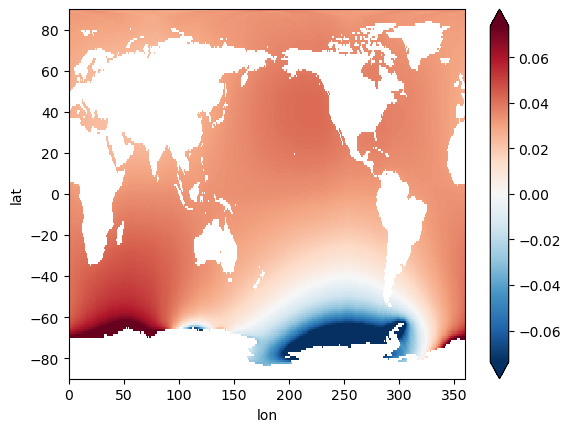

In [25]:
#test with function:



function_rsl = ky.sealevelfunctions(totalant, lon_target, lat_target, union_mask)#landsea)

(function_rsl/22).plot(robust=True, cmap="RdBu_r")



Jaar
2002
Jaar
2003
Jaar
2004
Jaar
2005
Jaar
2006
Jaar
2007
Jaar
2008
Jaar
2009
Jaar
2010
Jaar
2011
Jaar
2012
Jaar
2013
Jaar
2014
Jaar
2015
Jaar
2016
Jaar
2017
Jaar
2018
Jaar
2019
Jaar
2020
Jaar
2021
Jaar
2022
Jaar
2023
Jaar
2024


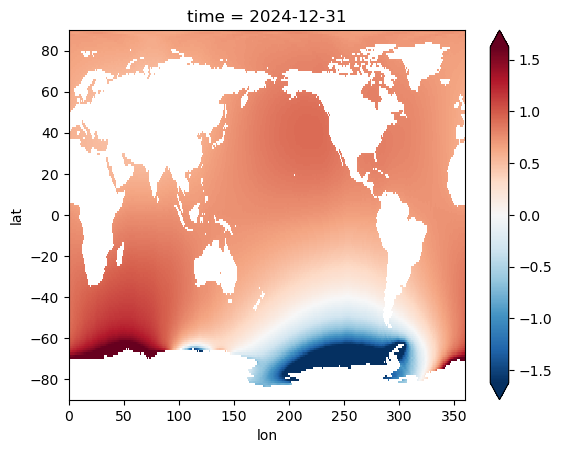

In [26]:
totalant2 = dm_lonlat_zero.isel(time=-7) - dm_lonlat_zero.isel(time=0) #this is how totalant is calculated for the last year
antreference = dm_lonlat_zero - dm_lonlat_zero.isel(time=0)


results = []
step=2001
for t in antreference.time:
    step=step+1
    print('Jaar')
    print(step) 
    totalant_t = antreference.sel(time=t)
    hoi_t = ky.sealevelfunctions(totalant_t, lon_target, lat_target, union_mask)
    results.append(hoi_t)

# Combine all time slices into a single xarray DataArray
hoi_all = xr.concat(results, dim=antreference.time)
hoi_all["time"] = antreference.time



# Plot an example year
hoi_all.isel(time=-1).plot(robust=True, cmap="RdBu_r")

hoi=ky.sealevelfunctions(totalant2, lon_target, lat_target, union_mask)

#hoi.plot(robust=True, cmap="RdBu_r")



<xarray.DataArray (lat: 180, lon: 360)> Size: 518kB
array([[       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       ...,
       [0.71099374, 0.71017087, 0.70849767, ..., 0.70805089, 0.70990778,
        0.71090705],
       [0.68014654, 0.67680813, 0.67399717, ..., 0.69250639, 0.68808576,
        0.68393465],
       [0.71828421, 0.71612912, 0.71394707, ..., 0.72452826, 0.72248977,
        0.72040642]], shape=(180, 360))
Coordinates:
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5

Mean (ignoring NaNs): 0.5256903481950116


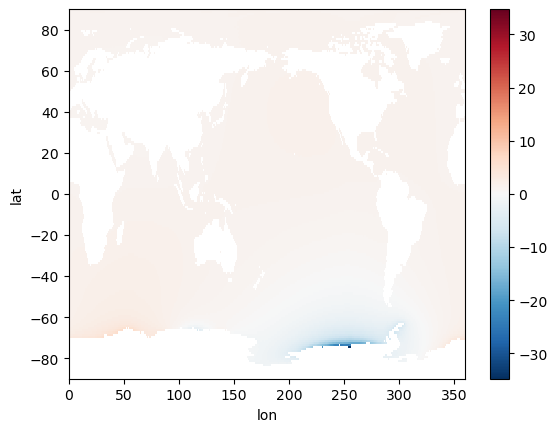

In [27]:
display(function_rsl)

mean_rsl = function_rsl.mean()#skipna=True)
print("Mean (ignoring NaNs):", mean_rsl.item())

fraction = function_rsl/mean_rsl.mean()
fraction.plot()

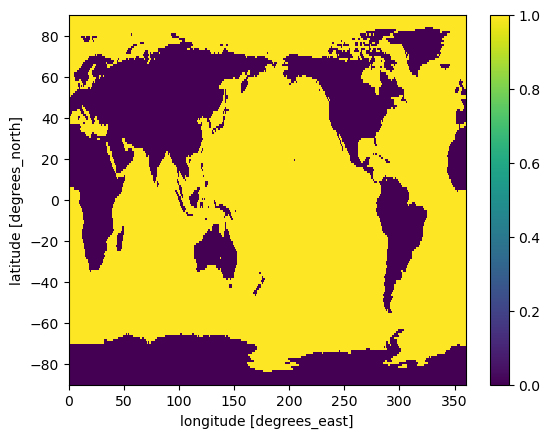

0.5256903481950103


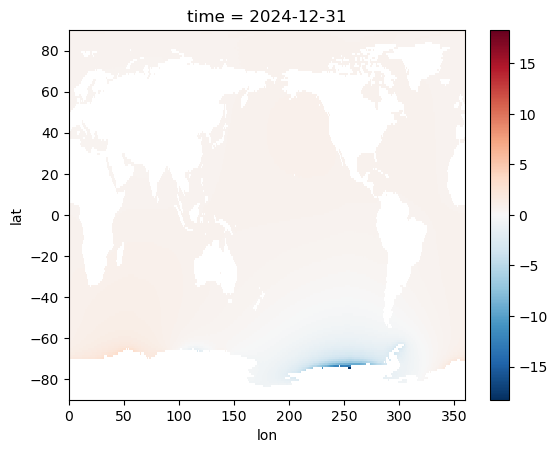

In [28]:

#Compute vmean
seamask = (union_mask == 0)
seamask.plot()
plt.show()
hoi_sea = hoi_all.isel(time=-1).where(seamask) 
hoi_sea.plot()
vmean = np.nanmean(hoi_sea)
print(vmean)



[ 1  3  6  8 11 14 16 19 22]
0
lala olieblol
blub
1
lala olieblol
blub
2
lala olieblol
blub
3
lala olieblol
blub
4
lala olieblol
blub
5
lala olieblol
blub
6
lala olieblol
blub
7
lala olieblol
blub
8
lala olieblol
blub


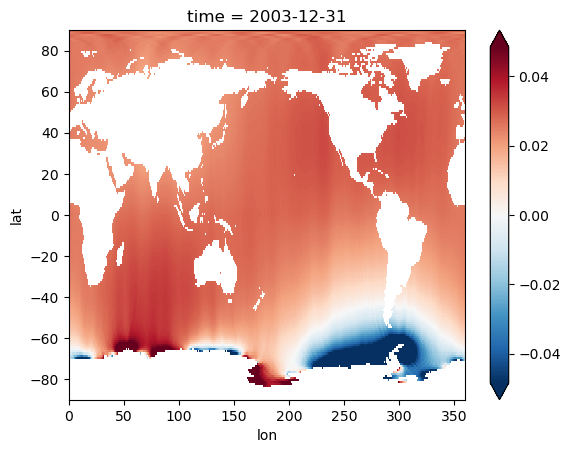

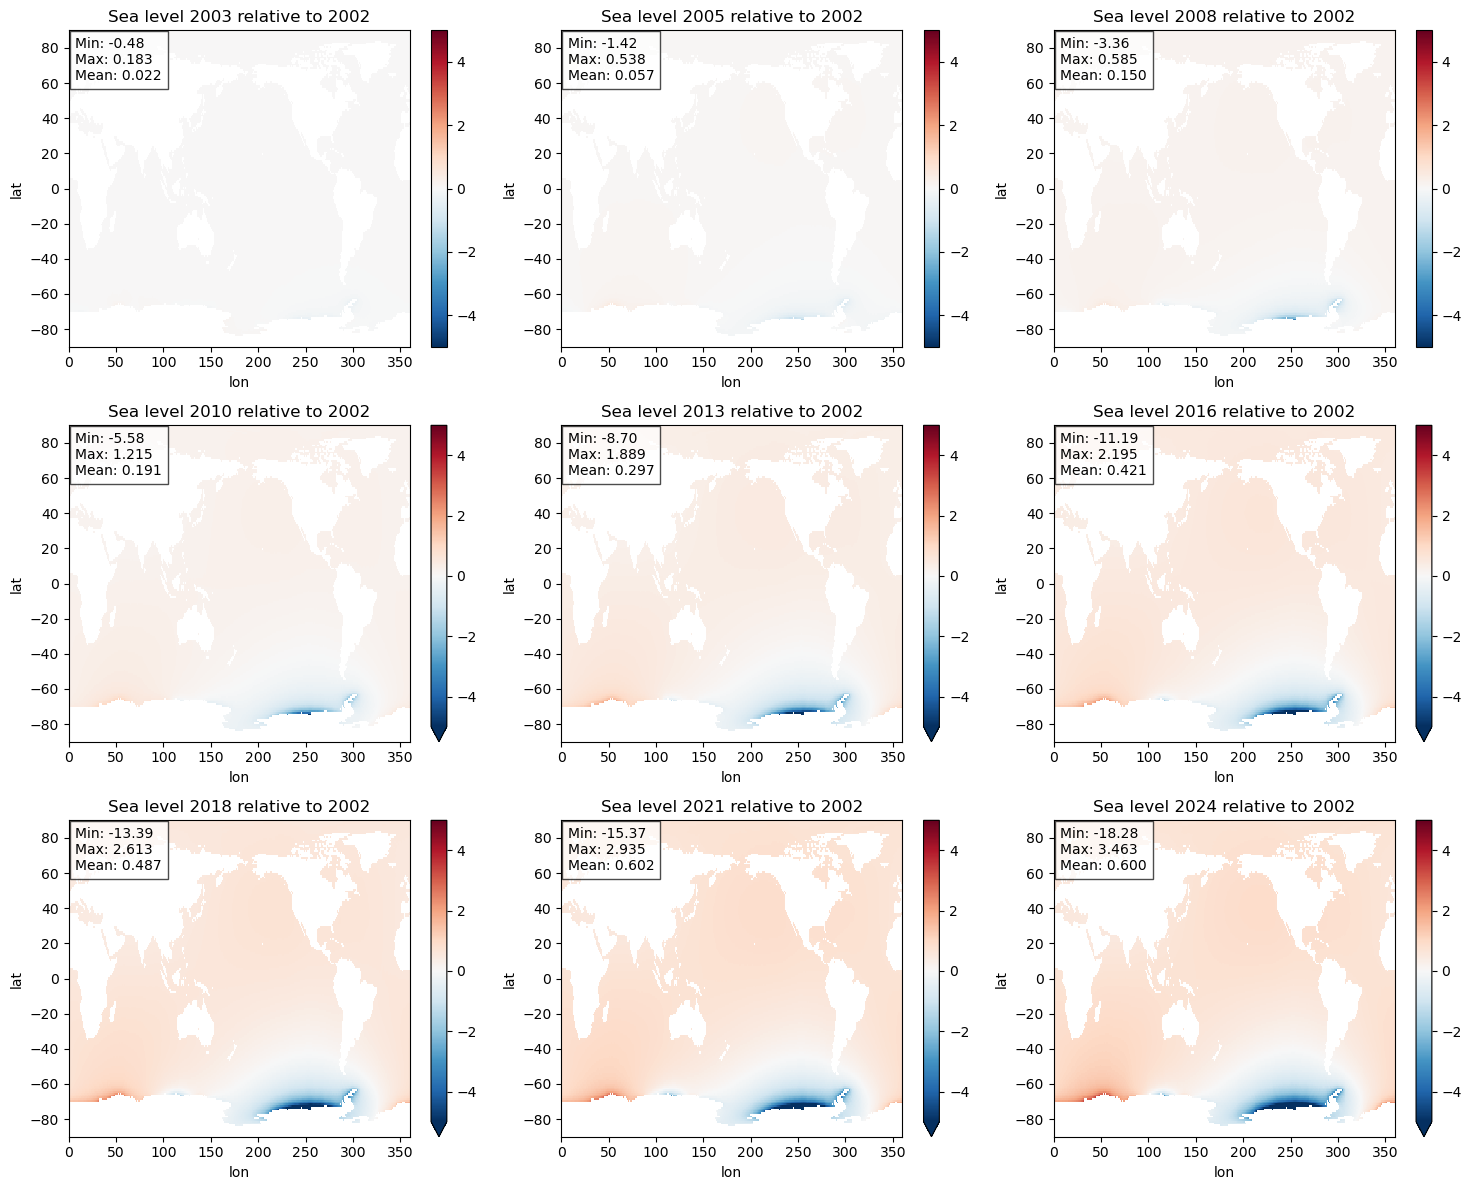

In [29]:
#display(hoi_all)
# Plot an example year
hoi_all.isel(time=1).plot(robust=True, cmap="RdBu_r")

hoi=ky.sealevelfunctions(totalant2, lon_target, lat_target, union_mask)

#hoi.plot(robust=True, cmap="RdBu_r")


# Pick 9 time indices spanning from 0 to 22 (inclusive)
time_indices = np.linspace(1, 22, 9, dtype=int)

print(time_indices)

# Create a 3x3 grid of subplots
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()



for i, ax in enumerate(axes):
    
    print(i)
    t = time_indices[i]
    time = 2002 + time_indices[i]
    
    hoi_all.isel(time=t).plot(ax=ax, cmap="RdBu_r", vmin=-5, vmax=5)


    # Compute min, max, mean
    data = hoi_all.isel(time=t).values
    vmin = np.nanmin(data)
    vmax = np.nanmax(data)


    #Compute vmean
    

    
    seamask = (union_mask == 0)
    hoi_sea = hoi_all.isel(time=t).where(seamask) 

    print('lala olieblol')

    weights = area_da.where(seamask)
    
    vmean = (hoi_sea*weights).sum(skipna=True)/weights.sum(skipna=True)

    #Aant_y['area']
    print('blub') 

    #vmean_list.append(vmean)

    # Add a box with the stats
    stats_text = f"Min: {vmin:.2f}\nMax: {vmax:.3f}\nMean: {vmean:.3f}"
    ax.text(
        0.02, 0.98, stats_text, transform=ax.transAxes, 
        fontsize=10, verticalalignment='top', 
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='black')
    )

    
    ax.set_title(f"Sea level {time} relative to 2002")

plt.tight_layout()


plt.savefig("C:/Users/kyrab/OneDrive/Afbeeldingen/sealevelrisyears", dpi=300, bbox_inches="tight")

plt.show()



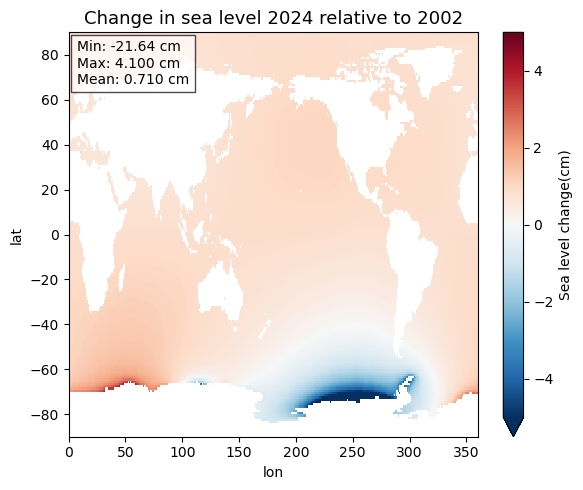

In [44]:
import matplotlib.pyplot as plt
import numpy as np

# ---- Select time index for 2024 relative to 2002 ----
# (consistent with your definition: time = 2002 + index)
t = 22
time = 2002 + t

# ---- Select data ----
hoi_2024 = hoi_all.isel(time=t)*1.1837950465122913

# ---- Compute min & max ----
data = hoi_2024.values
vmin = np.nanmin(data)
vmax = np.nanmax(data)

# ---- Compute area-weighted mean over sea only ----
seamask = (union_mask == 0)
hoi_sea = hoi_2024.where(seamask)
weights = area_da.where(seamask)

vmean = (hoi_sea * weights).sum(skipna=True) / weights.sum(skipna=True)
vmean = vmean.values

# ---- Plot single panel ----
fig, ax = plt.subplots(figsize=(6, 5))

hoi_2024.plot(
    ax=ax,
    cmap="RdBu_r",
    vmin=-5,
    vmax=5,
    cbar_kwargs={'label': 'Sea level change(cm)'}
)

# ---- Stats box ----
stats_text = (
    f"Min: {vmin:.2f} cm\n"
    f"Max: {vmax:.3f} cm\n"
    f"Mean: {vmean:.3f} cm"
)
ax.text(
    0.02, 0.98, stats_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='black')
)

ax.set_title("Change in sea level 2024 relative to 2002", fontsize=13)

plt.tight_layout()
plt.show()


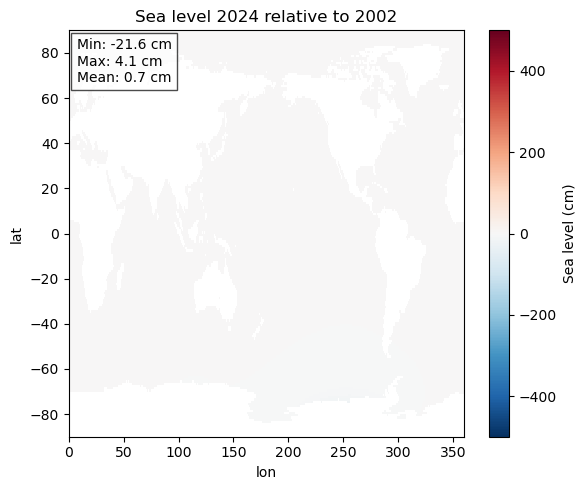

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# ---- Select time index for 2024 relative to 2002 ----
t = 22
time = 2002 + t

# ---- Select data ----
hoi_2024 = hoi_all.isel(time=t) * 1.1837950465122913

data = hoi_2024.values
vmin = np.nanmin(data)
vmax = np.nanmax(data)

# ---- Compute area-weighted mean over sea only in cm ----
seamask = (union_mask == 0)
hoi_sea = hoi_2024.where(seamask)
weights = area_da.where(seamask)

vmean = (hoi_sea * weights).sum(skipna=True) / weights.sum(skipna=True)
vmean = vmean.values

# ---- Plot single panel ----
fig, ax = plt.subplots(figsize=(6, 5))

c = hoi_2024.plot(
    ax=ax,
    cmap="RdBu_r",
    vmin=-500,  # nu in cm, bijvoorbeeld ±5 m → ±500 cm
    vmax=500,
    cbar_kwargs={'label': 'Sea level (cm)'}
)

# ---- Stats box in cm ----
stats_text = (
    f"Min: {vmin:.1f} cm\n"
    f"Max: {vmax:.1f} cm\n"
    f"Mean: {vmean:.1f} cm"
)
ax.text(
    0.02, 0.98, stats_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='black')
)

ax.set_title("Sea level 2024 relative to 2002")

plt.tight_layout()
plt.show()


In [31]:
seamask = (union_mask == 0)
hoi_sea = hoi_all.isel(time=-1)
#hoi_sea.plot()
#plt.show()
weights = area_da

weightedrise = hoi_sea*weights
vmean = weightedrise.where(seamask).sum(skipna=True)/weights.where(seamask).sum(skipna=True)
#weightedrise.plot()
#vmean = (hoi_sea*weights).sum(skipna=True)/weights.sum(skipna=True)

print(f"The area-weighted mean sea level change is {vmean.values:.4f}cm")

The area-weighted mean sea level change is 0.5998cm


In [32]:
# better way to calculate mean sea level rise (weighted mean) 

seamask = (union_mask == 0)
weights_masked = area_da.where(seamask)
hoi_masked = hoi_all.where(seamask) 


vmean2 = (hoi_masked * weights_masked).sum(dim=['lat', 'lon'], skipna=True) / weights_masked.sum(dim=['lat', 'lon'], skipna=True)

print(vmean2)


<xarray.DataArray (time: 23)> Size: 184B
array([0.        , 0.02192528, 0.04767494, 0.0570588 , 0.04848441,
       0.08323459, 0.14951181, 0.14631792, 0.19093602, 0.22395418,
       0.24012701, 0.29653609, 0.35369347, 0.41493081, 0.42091467,
       0.45628063, 0.486898  , 0.53777557, 0.57235288, 0.60198732,
       0.56737322, 0.56127968, 0.59977562])
Coordinates:
  * time     (time) datetime64[ns] 184B 2002-12-31 2003-12-31 ... 2024-12-31


In [33]:
# Calculate  the mean sea level rise due to antarctic melt for every timestep:
## WRONG NO AREA

# Mask ocean cells
hoi_sea = hoi_all.where(union_mask == 0)

# Compute mean over lat and lon, keeping only ocean

Antmeanrise = hoi_sea.mean(dim=['lat', 'lon'], skipna=True)

print(Antmeanrise)


<xarray.DataArray (time: 23)> Size: 184B
array([0.        , 0.01973329, 0.04215991, 0.04983167, 0.04167579,
       0.07286048, 0.13333129, 0.12745132, 0.16643739, 0.19454643,
       0.2078362 , 0.25826097, 0.30979614, 0.36527721, 0.37048806,
       0.40466016, 0.42885647, 0.47563691, 0.50704522, 0.53301582,
       0.49847871, 0.49090006, 0.52569035])
Coordinates:
  * time     (time) datetime64[ns] 184B 2002-12-31 2003-12-31 ... 2024-12-31


# Compare with frederikse


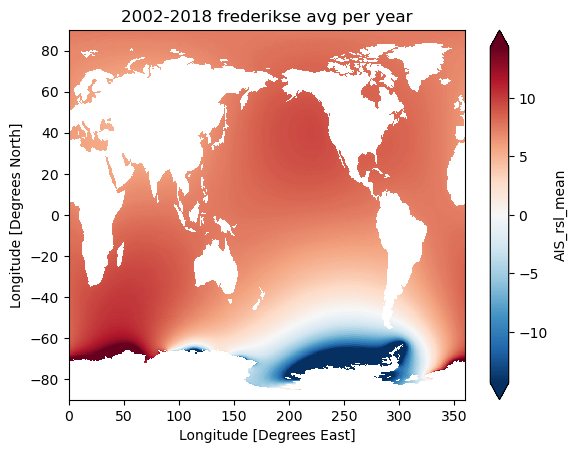

<xarray.DataArray (time: 23, lat: 180, lon: 360)> Size: 12MB
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [0.6652063 , 0.66475123, 0.66348497, ..., 0.661612  ,
         0.6635935 , 0.66481477],
        [0.63654725, 0.63339166, 0.63071659, ..., 0.64812605,
         0.64399884, 0.64011009],
        [0.669251  , 0.66713717, 0.66500267, ..., 0.67541074,
         0.6733936 , 0.67133841]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [0.71099374, 0.71017087, 0.70849767, ..., 0.70805089,
         0.70990778, 0.71090705],
        [0.68014654, 0.67680813, 0.67399717, ..., 0.69250639,
         0.68808576, 0.68393465],
        [0.71828421, 0.71612912, 0.71394707, ..., 0.72452826,
         0.72248977, 0.72040642]]], shape=(23, 180, 360))
Coordinates:
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * time     (time) datetime64[ns] 184B 2002-12-31 2003-12-31 ... 2024-12-31

<xarray.DataArray 'AIS_rsl_mean' ()> Size: 8B
array(-21.175)
<xarray.DataArray ()> Size: 8B
array(-18.27867094)


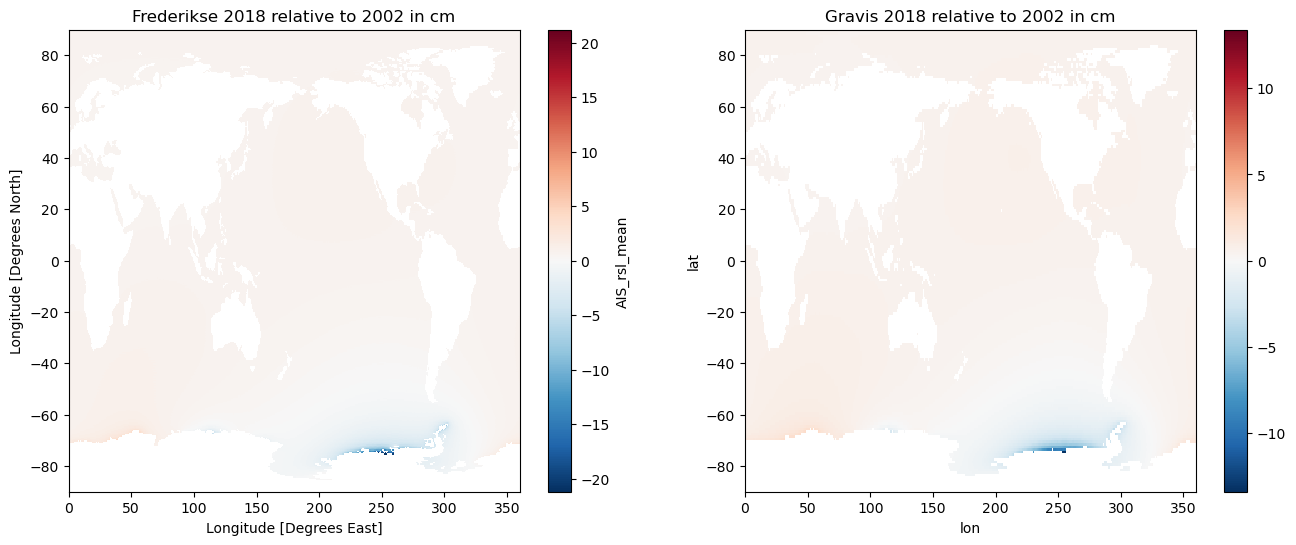

In [34]:
fred_dir = '../data/Frederikse2020/'

ant_ds = xr.open_dataset(f'{fred_dir}AIS.nc')

((ant_ds['AIS_rsl_mean'].isel(time=-1)-ant_ds['AIS_rsl_mean'].isel(time=102))).plot(robust=True, cmap="RdBu_r")


plt.title('2002-2018 frederikse avg per year')
plt.show()

frederikse2018 = ((ant_ds['AIS_rsl_mean'].sel(time=2018)-ant_ds['AIS_rsl_mean'].sel(time=2002)))


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

(frederikse2018*0.1).plot(ax=ax1, cmap="RdBu_r")#, vmin=-8, vmax=8) # Original is in cm, so now it is in mm
ax1.set_title('Frederikse 2018 relative to 2002 in cm')

hoi_all.isel(time=16).plot(ax=ax2, cmap="RdBu_r")#, vmin=-8, vmax=8) #, vmin=-2000, vmax=2000,
ax2.set_title('Gravis 2018 relative to 2002 in cm')

#ant_ds['AIS_rsl_mean'].isel(time=-1).plot(robust=True, cmap="RdBu_r")
#plt.show()


display(hoi_all)

minimum_fred = frederikse2018.min()*0.1
print(minimum_fred)
minimum_gravis = hoi_all.min()
print(minimum_gravis)



In [80]:
#Create same kind of dataset: 
print('hoi')

hoi


# Now save the data in a nc file 
Then i can use it in the budget and select an area 

In [34]:
# check layout of frederikse: 
display(ant_ds)
#display(hoi_all)


<xarray.Dataset> Size: 987MB
Dimensions:        (time: 119, lat: 360, lon: 720)
Coordinates:
  * lon            (lon) float32 3kB 0.25 0.75 1.25 1.75 ... 358.8 359.2 359.8
  * lat            (lat) float32 1kB -89.75 -89.25 -88.75 ... 88.75 89.25 89.75
  * time           (time) int16 238B 1900 1901 1902 1903 ... 2015 2016 2017 2018
Data variables:
    AIS_rsl_mean   (time, lat, lon) float64 247MB ...
    AIS_rsl_sterr  (time, lat, lon) float64 247MB ...
    AIS_rad_mean   (time, lat, lon) float64 247MB ...
    AIS_rad_sterr  (time, lat, lon) float64 247MB ...
Attributes:
    copyright:  This work is licensed under the Creative Commons Attribution-...

In [35]:
# create a nc file with the same format as the data from frederikse to be able to use it easily in the budget 

# translate the datetime of hoi to an array with years: 

ant_costg = xr.Dataset(
    coords = {
        'lon': hoi_all['lon'].values, 
        'lat': hoi_all['lat'].values,
        'time': hoi_all['time'].dt.year.values
    },
    data_vars = {
        'AIS_Gravis': (['time', 'lat', 'lon'], hoi_all.values),
        'Meanslr': (['time'], vmean2.values)
    },
    attrs = {
        'Info': 'Based on Gravis data and created using the gravity toolkit',
    }
)

ant_costg['lon'].attrs = {'long_name': 'Longitude', 'units': 'Degrees East'}
ant_costg['lat'].attrs = {'long_name': 'Latitude', 'units': 'Degrees North'}
ant_costg['time'].attrs = {'long_name': 'time (yearly average)', 'standard_name': 'time',  'units': 'years', 'axis': 'T'}


ant_costg['Meanslr'].attrs = {
    'long_name': 'Mean AIS_Gravis over ocean',
    'description': 'Mean over all ocean grid cells (union_mask==0)',
    'units': 'm'
}

display(ant_costg) 

<xarray.Dataset> Size: 12MB
Dimensions:     (time: 23, lat: 180, lon: 360)
Coordinates:
  * lon         (lon) float64 3kB 0.5 1.5 2.5 3.5 ... 356.5 357.5 358.5 359.5
  * lat         (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * time        (time) int64 184B 2002 2003 2004 2005 ... 2021 2022 2023 2024
Data variables:
    AIS_Gravis  (time, lat, lon) float64 12MB nan nan nan ... 0.7225 0.7204
    Meanslr     (time) float64 184B 0.0 0.02193 0.04767 ... 0.5674 0.5613 0.5998
Attributes:
    Info:     Based on Gravis data and created using the gravity toolkit

In [36]:
import os

print(output_path)
print(os.path.exists(output_path))

ant_costg.to_netcdf(output_path + 'Gravis_Ant_new_weighted.nc')

../outputs/Gravis_Antarctica/
True


PermissionError: [Errno 13] Permission denied: 'C:\\Users\\kyrab\\Github\\SLBudget\\outputs\\Gravis_Antarctica\\Gravis_Ant_new_weighted.nc'